# Lorena's Bioprocess Model

This model aims to describe a growth system of *Pseudomonas putida* in different
set-ups. The model not only studies the microorganism’s growth dynamics
but also the consumption of a carbon source (substrate) and other nutrients
(chemical elements). Additionally, it examines the dynamics of gases that may
be used in the process, including both those in the gas phase of the system and
those dissolved in the liquid phase.

For further information, please check the [*BIOS_Pseudomonas_model.pdf*](misc/BIOS_Pseudomonas_model.pdf) document associated with this notebook in the *misc* folder.

In [1]:
# Lorena Bioprocess Model — Modular ODEs with flexible fed modes
# Requirements: numpy, scipy
from bioreactor_core_model import *

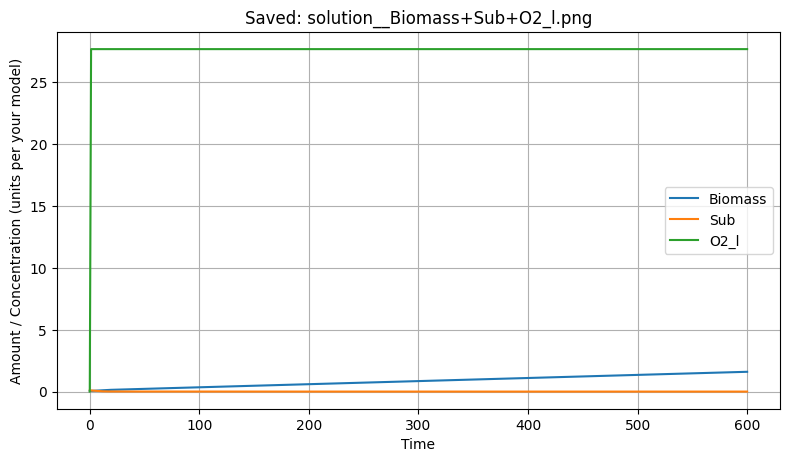

Inputs saved to: ./playground_folders/inputs
Solution files: {'npz': 'playground_folders/outputs/solution.npz', 'csv': 'playground_folders/outputs/solution.csv', 'params_json': 'playground_folders/outputs/solution.params.json', 'initials_json': 'playground_folders/outputs/solution.initials.json'}


In [2]:
# pipeline
if __name__ == "__main__":
    # 0) Build a reproducible set of INPUTS
    inputs = assemble_inputs(
        params=minimal_parameters(),
        initials=minimal_initials(),
        mode_name="fed-batch",
        mode_consts={"Vf_const": 0.01, "Vs_const": 0.0, "VGasIn_const": 0.1, "VOffGas_const": 0.1},
        t_span=(0.0, 600.0),
        t_eval=None,             # or np.linspace(0, 600, 501)
        method="LSODA",
        rtol=1e-6,
        atol=1e-9
    )

    # 1) Save INPUTS only (so you can re-run later identically)
    inputs_dir = "./playground_folders/inputs"
    outputs_dir = "./playground_folders/outputs"
    save_model_inputs(inputs, out_dir=inputs_dir, basename="inputs")

    # 2) (At any later time) Reload those inputs
    loaded = load_model_inputs(inputs_dir, basename="inputs")

    # 3) Simulate from the loaded inputs (no surprises)
    sol = run_from_inputs(loaded)

    # 4) Save the numerical SOLUTION + metadata (CSV/NPZ/JSON)
    written = save_solution(sol, loaded["params"], loaded["initials"],
                            out_dir=outputs_dir, basename="solution")

    # 5) Plot a few series and save the figure
    plot_timeseries(
        sol,
        variables=["Biomass", "Sub", "O2_l"],
        out_dir=outputs_dir,
        basename="solution__Biomass+Sub+O2_l",
        show=True,   # set False for headless runs
        save=True
    )

    print("Inputs saved to:", inputs_dir)
    print("Solution files:", written)
